### Student Performance Analysis (EDA)
The notebook works with dataset, containing information about Students Performance in exam.

Goals:-

1-Identification of clusters of excellent, good and poor performing students, using K-Means algorithm

2-Comparision of exam results of the students from each cluster

3-Visualization of excellent performance cluster characteristics

### student performance in exam

In [29]:
import numpy as np
import pandas as pd 
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder 

students_data = pd.read_csv(r"E:\Training\Data Science\Sessions\Technical\python training codes\Trials\projects\project1\StudentsPerformance.csv")
students_data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### K-Means algorithm
Identifying clusters

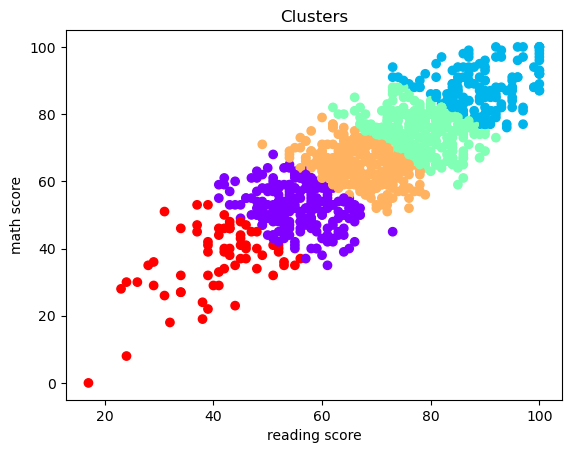

In [30]:
#Number of clusters set for 5
kmeans = KMeans(5)

#Clustering based on reading and math scores
kmeans.fit(students_data.loc[:,["reading score", "math score"]])
identified_clusters = kmeans.fit_predict(students_data.loc[:,["reading score", "math score"]])

#Adding a column to the dataset with cluster fit 
data_with_clusters = students_data.copy()
data_with_clusters["Cluster"] = identified_clusters

plt.scatter(data_with_clusters["reading score"], data_with_clusters["math score"], 
            c = data_with_clusters["Cluster"], cmap = "rainbow")
plt.title("Clusters")
plt.xlabel("reading score")
plt.ylabel("math score")
plt.show()

### Evaluation with elbow method¶
Trying to find a "sweet spot" between number of clusters and the sum of squared error

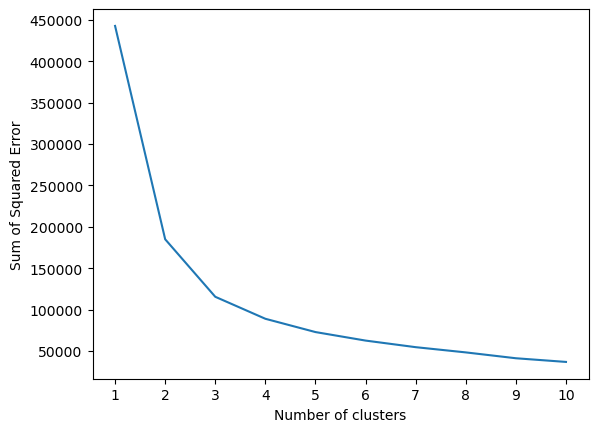

In [31]:
#Trying out different numbers as the number of clusters 
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(students_data.loc[:,["reading score", "math score"]])
    #Computing the sum of squared error for each
    sse.append(kmeans.inertia_)


plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of clusters")
plt.ylabel("Sum of Squared Error")
plt.show()

### "The sweet spot" from the elbow method is the point, where curve starts to bend. The best value seems to be "3", thus below K-Means algorithm is used again to identify clusters, but this time only three.

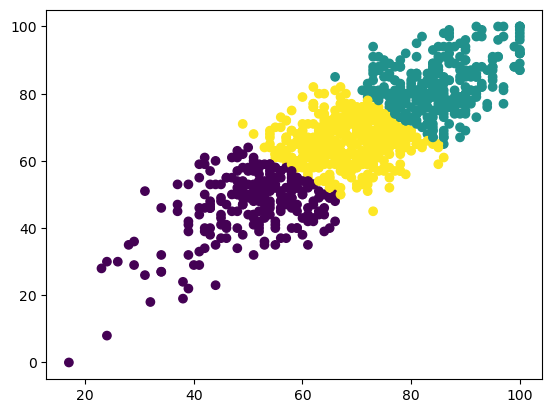

In [32]:
#Algorithm, fitting + adding info about clusters to data set
kmeans = KMeans(3)
kmeans.fit(students_data.loc[:,["reading score", "math score"]])
identified_clusters = kmeans.fit_predict(students_data.loc[:,["reading score", "math score"]])
students_data["Cluster"] = identified_clusters

#Visualization
plt.scatter(students_data["reading score"], students_data["math score"], c = students_data["Cluster"])
plt.show()

### Comparision of performance of students from different clusters in the exams

In [33]:
excellent_performance = data_with_clusters[data_with_clusters["Cluster"] == 0]
good_performance = data_with_clusters[data_with_clusters["Cluster"] == 1]
poor_performance = data_with_clusters[data_with_clusters["Cluster"] == 2]

C:\Users\Mohammed\AppData\Local\Temp\ipykernel_9020\1861979396.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=excellent_performance['math score'], label="excellent performance", shade=True)
C:\Users\Mohammed\AppData\Local\Temp\ipykernel_9020\1861979396.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=good_performance['math score'], label="good performance", shade=True)
C:\Users\Mohammed\AppData\Local\Temp\ipykernel_9020\1861979396.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=poor_performance['math score'], label="poor performance", shade=True)


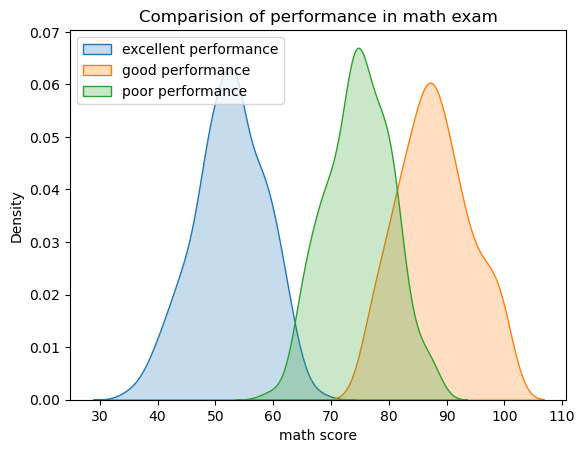

In [34]:
sns.kdeplot(data=excellent_performance['math score'], label="excellent performance", shade=True)
sns.kdeplot(data=good_performance['math score'], label="good performance", shade=True)
sns.kdeplot(data=poor_performance['math score'], label="poor performance", shade=True)
plt.title("Comparision of performance in math exam")
plt.legend(loc = "upper left")

C:\Users\Mohammed\AppData\Local\Temp\ipykernel_9020\3188202257.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=excellent_performance['reading score'], label="excellent performance", shade=True)
C:\Users\Mohammed\AppData\Local\Temp\ipykernel_9020\3188202257.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=good_performance['reading score'], label="good performance", shade=True)
C:\Users\Mohammed\AppData\Local\Temp\ipykernel_9020\3188202257.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=poor_performance['reading score'], label="poor performance", shade=True)


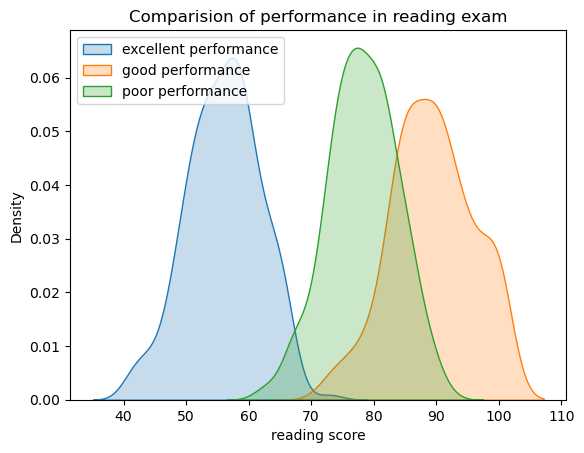

In [35]:
sns.kdeplot(data=excellent_performance['reading score'], label="excellent performance", shade=True)
sns.kdeplot(data=good_performance['reading score'], label="good performance", shade=True)
sns.kdeplot(data=poor_performance['reading score'], label="poor performance", shade=True)
plt.title("Comparision of performance in reading exam")
plt.legend(loc = "upper left")

### Cluster characteristics - Students with excellent performance
Simple analysis and visualizations to characterize students from excellent_performance cluster

Text(0.5, 1.0, 'Gender ratio')

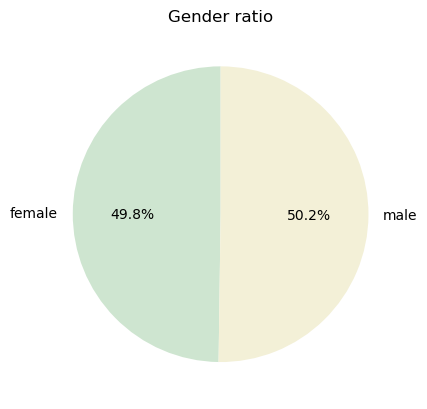

In [37]:
#gender analysis
gender_share = [len(excellent_performance[excellent_performance["gender"] == "female"]), len(excellent_performance[excellent_performance["gender"] == "male"])]

plt.pie(gender_share, labels = ["female", "male"], colors = ["#CEE5D0", "#F3F0D7"], autopct = '%1.1f%%', startangle = 90)
plt.title("Gender ratio")

Text(0.5, 1.0, 'Ethnicity')

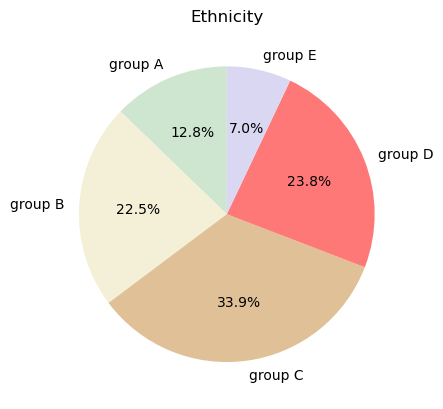

In [38]:
#ethnicity
ethnicity = excellent_performance["race/ethnicity"].unique()
ethnicity_share = [len(excellent_performance[excellent_performance["race/ethnicity"] == group]) for group in ethnicity]

plt.pie(ethnicity_share, labels = ethnicity, colors = ["#CEE5D0", "#F3F0D7", "#E0C097", "#FF7878", "#D9D7F1"], autopct = '%1.1f%%', startangle = 90)
plt.title("Ethnicity")

Text(0.5, 1.0, 'Parental level of education')

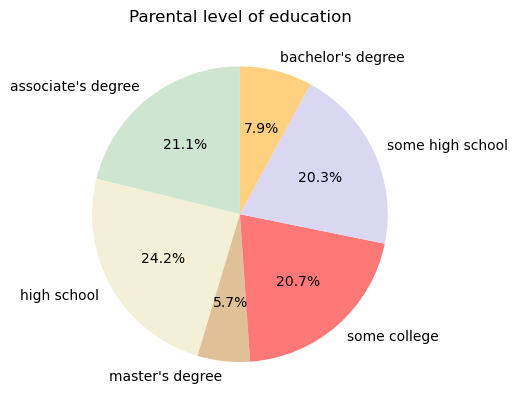

In [39]:
parents = excellent_performance["parental level of education"].unique()
parents_share = [len(excellent_performance[excellent_performance["parental level of education"] == group]) for group in parents]

plt.pie(parents_share, labels = parents, colors = ["#CEE5D0", "#F3F0D7", "#E0C097", "#FF7878", "#D9D7F1", "#FFD07F"], autopct = '%1.1f%%', startangle = 90)
plt.title("Parental level of education")

Text(0.5, 1.0, 'Lunch')

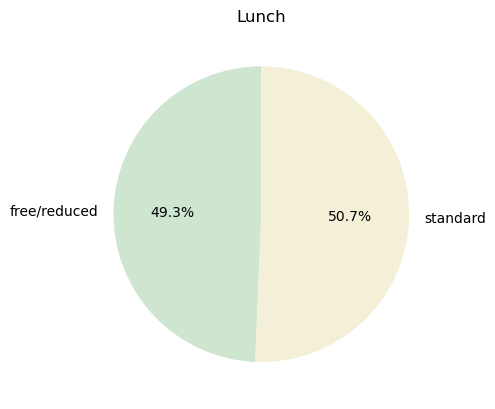

In [40]:
lunch = excellent_performance["lunch"].unique()
lunch_share = [len(excellent_performance[excellent_performance["lunch"] == group]) for group in lunch]

plt.pie(lunch_share, labels = lunch, colors = ["#CEE5D0", "#F3F0D7"], autopct = '%1.1f%%', startangle = 90)
plt.title("Lunch")

Text(0.5, 1.0, 'Test prepatation course')

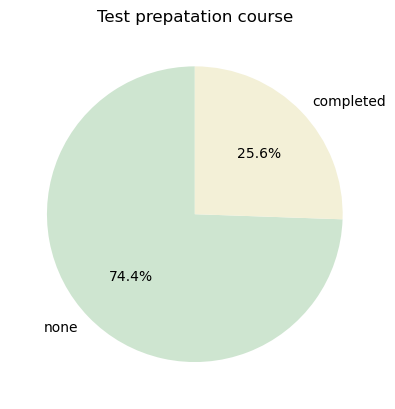

In [41]:
preparation = excellent_performance["test preparation course"].unique()
preparation_share = [len(excellent_performance[excellent_performance["test preparation course"] == group]) for group in preparation]

plt.pie(preparation_share, labels = preparation, colors = ["#CEE5D0", "#F3F0D7"], autopct = '%1.1f%%', startangle = 90)
plt.title("Test prepatation course")

In [42]:
poor_performance.describe()

,math score,reading score,writing score,Cluster
count,262.000000,262.000000,262.000000,262.0
mean,74.736641,78.179389,76.809160,2.0
std,5.659166,5.568992,6.534453,0.0
min,59.000000,62.000000,61.000000,2.0
25%,71.000000,74.000000,72.000000,2.0
50%,75.000000,78.000000,77.000000,2.0
75%,79.000000,82.000000,81.750000,2.0
max,88.000000,92.000000,92.000000,2.0


### Conclusion
1-Optimal number of clusters in case of math and reading score classification was three.

2-Students were classified into groups of excellent, good and poor performance

3-KDE plots show difference between student performance from those clusters.

4-excellent performace is usually around 85%, good 65%, poor 35%

5-Characteristics of students with excellent performance:-

Students with excellent performance are usually female and had standard lunch. Students from this cluster are divided "half/half", when it comes to preparation course. Parents of 26.6% students have associate's degree and the biggest shares of ethnicity among the students have group C, D and E.

## Some Visualizations on Data

### Pie Chart For Race\Ethnicity

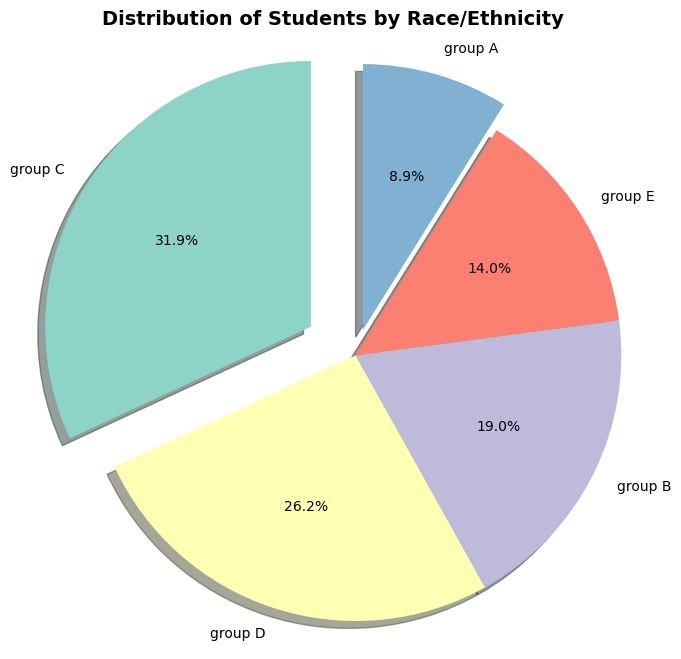

In [86]:
# Count values
counts = students_data['race/ethnicity'].value_counts()

# Explode all slices slightly
explode = [0.2, 0, 0, 0, 0.1] #* len(counts)

# Color palette
colors = plt.cm.Set3.colors

plt.figure(figsize=(8, 8))

plt.pie(
    counts,
    labels=counts.index,          # correct labels
    autopct='%1.1f%%',            # show percentages
    startangle=90,               # rotate chart
    explode=explode,
    colors=colors,
    shadow=True
)

plt.title('Distribution of Students by Race/Ethnicity',
          fontsize=14, fontweight='bold')

plt.axis('equal')  # keep it circular

plt.show()

### Box Plot For Good Performance grades in Math

In [44]:
good_performance.describe()

,math score,reading score,writing score,Cluster
count,151.000000,151.000000,151.000000,151.0
mean,87.933775,89.357616,88.291391,1.0
std,6.205018,6.532324,7.533560,0.0
min,76.000000,73.000000,69.000000,1.0
25%,83.500000,85.000000,83.000000,1.0
50%,88.000000,89.000000,89.000000,1.0
75%,92.000000,94.000000,94.000000,1.0
max,100.000000,100.000000,100.000000,1.0


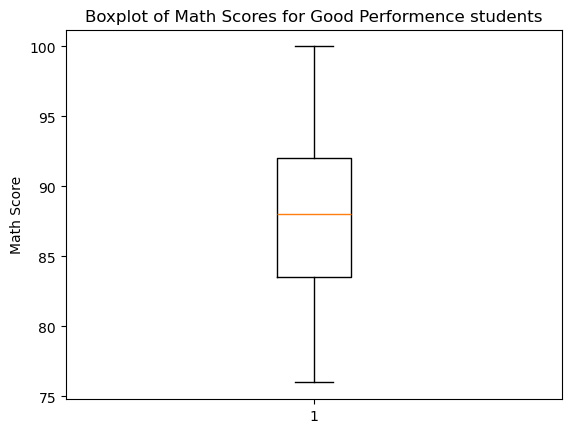

,math score,reading score,writing score,Cluster
count,151.000000,151.000000,151.000000,151.0
mean,87.933775,89.357616,88.291391,1.0
std,6.205018,6.532324,7.533560,0.0
min,76.000000,73.000000,69.000000,1.0
25%,83.500000,85.000000,83.000000,1.0
50%,88.000000,89.000000,89.000000,1.0
75%,92.000000,94.000000,94.000000,1.0
max,100.000000,100.000000,100.000000,1.0


In [45]:
plt.boxplot(good_performance["math score"])
plt.ylabel("Math Score")
plt.title("Boxplot of Math Scores for Good Performence students")
plt.show()
good_performance.describe()

### Add new clumn " category type" to df then display total no. of students in each category

In [48]:
# Step 1: Define cluster labels
cluster_labels = {
    0: "excellent_performance",
    1: "good_performance",
    2: "poor_performance"
}

# Step 2: Add new column to DataFrame
students_data["Cluster_Category"] = students_data["Cluster"].map(cluster_labels)

# Step 3: Count number of students in each category
category_counts = students_data["Cluster_Category"].value_counts()

# Step 4: Display result
print(category_counts)

Cluster_Category
poor_performance         447
good_performance         307
excellent_performance    246
Name: count, dtype: int64


### Display data Usin Pandas with new added "Cluster_Name" Column

In [59]:
students_data.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Cluster,Cluster_Category,Cluster_Name
0,female,group B,bachelor's degree,standard,none,72,72,74,2,poor_performance,poor_performance
1,female,group C,some college,standard,completed,69,90,88,1,good_performance,good_performance
2,female,group B,master's degree,standard,none,90,95,93,1,good_performance,good_performance
3,male,group A,associate's degree,free/reduced,none,47,57,44,0,excellent_performance,excellent_performance
4,male,group C,some college,standard,none,76,78,75,1,good_performance,good_performance
5,female,group B,associate's degree,standard,none,71,83,78,1,good_performance,good_performance
6,female,group B,some college,standard,completed,88,95,92,1,good_performance,good_performance
7,male,group B,some college,free/reduced,none,40,43,39,0,excellent_performance,excellent_performance
8,male,group D,high school,free/reduced,completed,64,64,67,2,poor_performance,poor_performance
9,female,group B,high school,free/reduced,none,38,60,50,0,excellent_performance,excellent_performance


## Bar Chatrt for Student 3 Categories

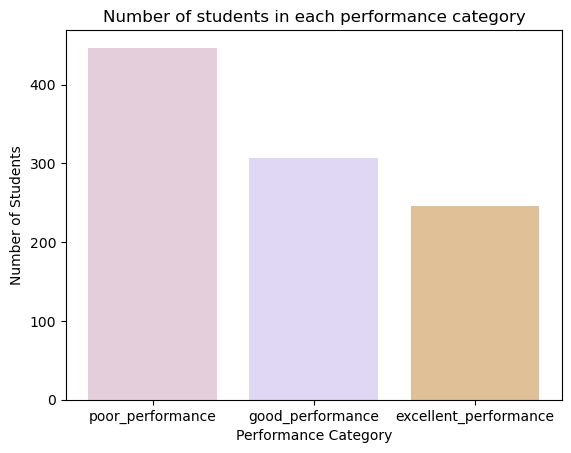

In [56]:
plt.bar(category_counts.index, category_counts.values, color = ["#E5CEDB", "#DFD7F3", "#E0C097"])
plt.title("Number of students in each performance category")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.show()

## Pie Chatrt for Student 3 Categories

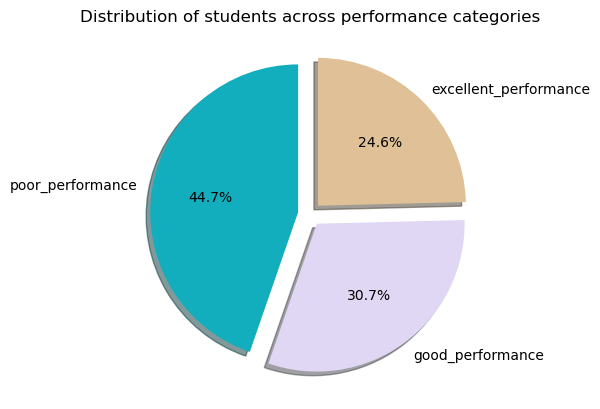

In [80]:
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', colors = ["#12AEBD", "#DFD7F3", "#E0C097"], startangle = 90, explode = [0.08] * len(category_counts), shadow = True)
plt.title("Distribution of students across performance categories")
plt.show()

### Another way to display total no. of students in each category by matplotlib

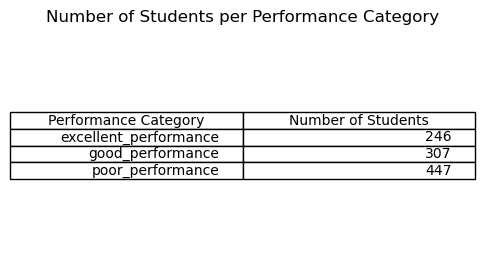

In [53]:
# Step 1: Define cluster labels
cluster_labels = {
    0: "excellent_performance",
    1: "good_performance",
    2: "poor_performance"
}

# Step 2: Map labels
students_data["Cluster_Name"] = students_data["Cluster"].map(cluster_labels)

# Step 3: Count values using names
counts = students_data["Cluster_Name"].value_counts()

# Optional: order the categories
counts = counts.reindex(["excellent_performance", "good_performance", "poor_performance"])

# Step 4: Convert to DataFrame
table_data = counts.reset_index()
table_data.columns = ["Performance Category", "Number of Students"]
# Step 5: Plot table
plt.figure(figsize=(6, 3))
plt.table(cellText=table_data.values,
          colLabels=table_data.columns,
          loc='center')
plt.axis('off')  # Hide axes
plt.title("Number of Students per Performance Category")
plt.show()